In [ ]:
# !pip install opendatasets --quiet

In [1]:
import os
import zipfile

In [2]:
!pwd

/content


In [3]:
os.listdir()

['.config', 'kaggle.json', 'sample_data']

In [4]:
%mkdir ~/.kaggle



In [5]:
%mv /content/kaggle.json ~/.kaggle/

In [6]:
%cd /content/

/content


In [7]:
!chmod 600 ~/.kaggle/kaggle.json

# dowenload our dataset fr om kaggel

In [8]:
# !pip install --upgrade kaggle
#

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 16.6 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [9]:
!kaggle datasets download andrewmvd/animal-faces

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 696M/696M [00:07<00:00, 93.0MB/s]



In [10]:
with zipfile.ZipFile('/content/animal-faces.zip','r') as zip_ref :
  zip_ref.extractall('/content/animal-faces')

# start import our Libraries

In [11]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torch.nn as nn
from torch.utils.data import DataLoader , Dataset
from torch.optim import Adam
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import torch.nn.functional as F
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

### detect GPU

# Read our Data

In [42]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [43]:
image_path = []
labels = []

In [44]:
for i in os.listdir("/content/animal-faces/afhq") :
  for label in os.listdir("/content/animal-faces/afhq/"+i) :
    for image in os.listdir("/content/animal-faces/afhq/"+i+"/"+label) :
      image_path.append("/content/animal-faces/afhq/"+i+"/"+label+"/"+image)
      labels.append(label)



In [45]:
df = pd.DataFrame(
    {
        "image_path":image_path,
        "labels":labels
    }
)

In [46]:
df

,image_path,labels
0,/content/animal-faces/afhq/train/wild/pixabay_...,wild
1,/content/animal-faces/afhq/train/wild/pixabay_...,wild
2,/content/animal-faces/afhq/train/wild/pixabay_...,wild
3,/content/animal-faces/afhq/train/wild/flickr_w...,wild
4,/content/animal-faces/afhq/train/wild/flickr_w...,wild
...,...,...
16125,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
16126,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
16127,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
16128,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [47]:
df.shape

(16130, 2)

In [48]:
df['labels'].value_counts()

,count
labels,
cat,5653
dog,5239
wild,5238


In [49]:
X_train , X_test , y_train , y_test = train_test_split(df['image_path'] , df['labels'] , test_size=0.3 , stratify=df['labels'])

In [50]:
X_test , X_val , y_test , y_val = train_test_split(X_test , y_test , test_size=0.5 , stratify=y_test) # we use stratify to ensure percent of labels in all splits

In [51]:
train = pd.DataFrame(
    {
        "image_path":X_train,
        "labels":y_train
    }
)

In [52]:
test = pd.DataFrame(
    {
        "image_path":X_test,
        "labels":y_test
    }
)

In [53]:
val = pd.DataFrame(
    {
        "image_path":X_val,
        "labels":y_val
    }
)

In [54]:
train['labels'].value_counts()

,count
labels,
cat,3957
dog,3667
wild,3667


In [55]:
test['labels'].value_counts()

,count
labels,
cat,848
dog,786
wild,785


In [56]:
val['labels'].value_counts()

,count
labels,
cat,848
dog,786
wild,786


# start encode labels

In [57]:
label_encoder = LabelEncoder()
label_encoder.fit(train['labels'])

LabelEncoder()

In [58]:
transform = transforms.Compose([
    transforms.Resize((128 , 128)) ,
    transforms.ToTensor() ,
    transforms.ConvertImageDtype(torch.float)
])

# Create Custom Dataset Class

In [61]:
class CustomDataset(Dataset):
  def __init__(self , df , transform = None) :
    self.df = df
    self.transform = transform
    self.labels = torch.tensor(label_encoder.fit_transform(df['labels'])).to(device)
  def __len__(self) :
    return len(self.df)

  def __getitem__(self, idx):
    img_path = self.df.iloc[idx, 0]
    label = self.labels[idx]
    image = Image.open(img_path).convert('RGB')
    if self.transform:
      image = (self.transform(image).to(device))

    return image, label


In [62]:
trainset = CustomDataset(train , transform)
testset = CustomDataset(test , transform)
valset = CustomDataset(val , transform)

In [63]:
trainset.__len__()

11291

In [64]:
trainset.__getitem__(2)

(tensor([[[0.0275, 0.0667, 0.1412,  ..., 0.0157, 0.0157, 0.0235],
          [0.0431, 0.1098, 0.1137,  ..., 0.0196, 0.0157, 0.0235],
          [0.0824, 0.1176, 0.0549,  ..., 0.0196, 0.0196, 0.0118],
          ...,
          [0.4980, 0.5176, 0.5098,  ..., 0.0196, 0.0235, 0.0275],
          [0.5020, 0.5098, 0.5255,  ..., 0.0235, 0.0275, 0.0275],
          [0.5098, 0.5020, 0.5176,  ..., 0.0314, 0.0275, 0.0275]],
 
         [[0.0588, 0.1569, 0.2627,  ..., 0.0235, 0.0235, 0.0314],
          [0.1294, 0.2275, 0.2235,  ..., 0.0275, 0.0235, 0.0314],
          [0.2118, 0.2627, 0.1647,  ..., 0.0275, 0.0275, 0.0196],
          ...,
          [0.4627, 0.4863, 0.4902,  ..., 0.0235, 0.0275, 0.0314],
          [0.4706, 0.4824, 0.5059,  ..., 0.0275, 0.0314, 0.0314],
          [0.4745, 0.4706, 0.4941,  ..., 0.0353, 0.0314, 0.0314]],
 
         [[0.0549, 0.0980, 0.1686,  ..., 0.0196, 0.0196, 0.0275],
          [0.0627, 0.1373, 0.1451,  ..., 0.0235, 0.0196, 0.0275],
          [0.0941, 0.1412, 0.0863,  ...,

# visualize image

In [65]:
label_encoder.inverse_transform([1])

array(['dog'], dtype=object)

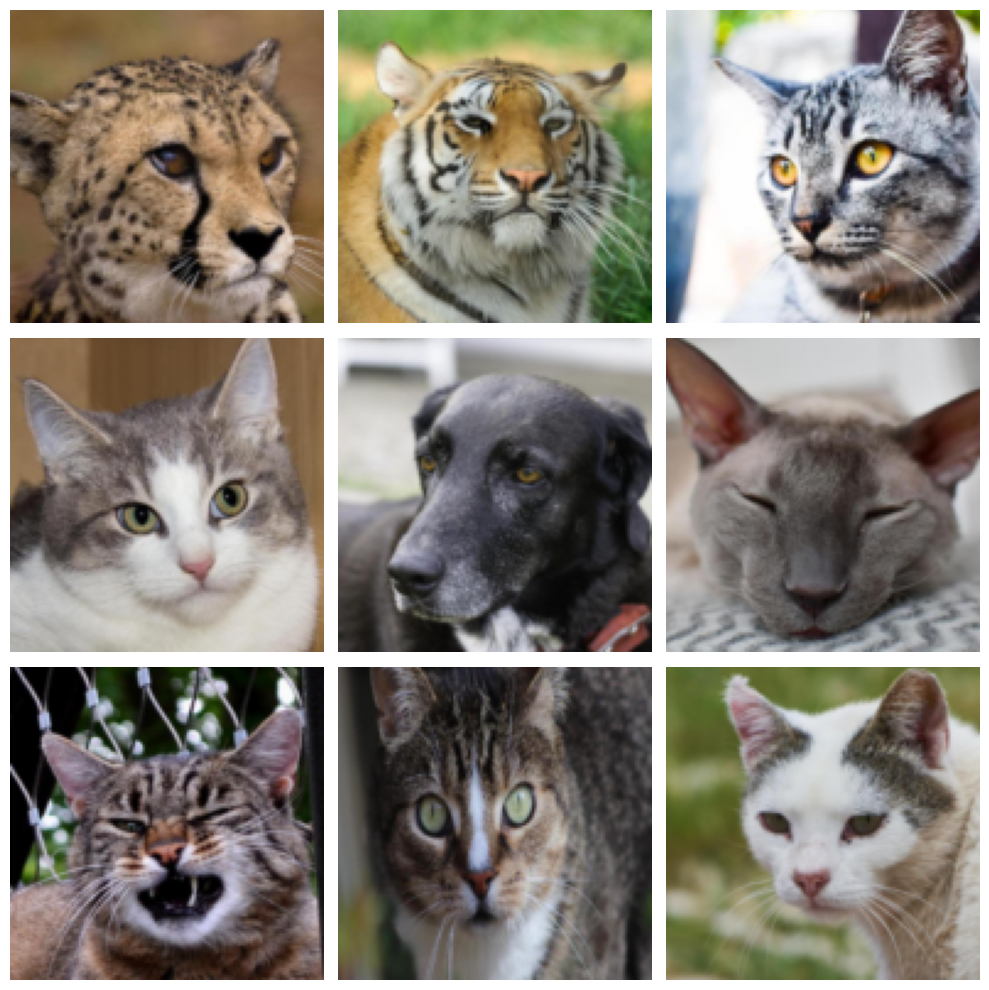

In [67]:
n_rows = 3
n_cols = 3
fig , axes = plt.subplots(n_rows , n_cols , figsize=(10,10))
for row in range(n_rows) :
  for col in range(n_cols) :
    idx = np.random.randint(0 , trainset.__len__())
    image , label = trainset.__getitem__(idx)
    image = image.cpu()
    axes[row , col].imshow(np.transpose(image.numpy().squeeze(), (1,2,0)))
    axes[row , col].axis('off')
plt.tight_layout()
plt.show()

# set hyperparameter

In [68]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

# Data Loader

In [69]:
trainloader = DataLoader(trainset , batch_size= BATCH_SIZE , shuffle=True)
testloader = DataLoader(testset , batch_size= BATCH_SIZE , shuffle=True)
valloader = DataLoader(valset , batch_size= BATCH_SIZE , shuffle=True)

# Model

In [70]:
class CNNNetwork(nn.Module):
  def __init__(self):
    super(CNNNetwork , self).__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1)
    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d( 2 , 2)
    self.conv2 = nn.Conv2d(32 , 64 , kernel_size=3 , padding=1 )
    self.conv3 = nn.Conv2d(64 , 128 , kernel_size= 3 , padding=1)
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(32768 , 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256 , 128)
    self.fc4 = nn.Linear(128 , len(trainset.labels.unique()))

  def forward(self , x) :
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)
    x = self.conv2(x)
    x = self.relu(x)
    x = self.pool(x)
    x = self.conv3(x)
    x = self.relu(x)
    x = self.pool(x)
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.fc3(x)
    x = self.relu(x)
    x = self.fc4(x)
    return x


# model summary

In [71]:
from torchsummary import summary
model = CNNNetwork().to(device)
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
              ReLU-5           [-1, 64, 64, 64]               0
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
              ReLU-8          [-1, 128, 32, 32]               0
         MaxPool2d-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 512]      16,777,728
             ReLU-12                  [-1, 512]               0
           Linear-13                  [-1, 256]         131,328
             ReLU-14                  [

# loss and optimizer

In [72]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters() , lr=LR)

# Start training

In [73]:
total_loss_train_plot = []
total_acc_train_plot = []
total_loss_val_plot = []
total_acc_val_plot = []


In [74]:
for epoch in range(EPOCHS) :
  train_loss = 0.0
  train_acc = 0.0
  val_loss = 0.0
  val_acc = 0.0
  for index , (X , y) in enumerate(trainloader) :
    # make zero for gradient
    optimizer.zero_grad()
    # forward pass
    y_pred = model(X)
    loss = criterion(y_pred , y)
    train_loss += loss.item()
    loss.backward()
    train_acc += (torch.argmax(y_pred , axis =1) == y).sum().item()
    optimizer.step()
  with torch.no_grad() :
    for index , (X , y) in enumerate(valloader) :
      y_pred = model(X)
      loss = criterion(y_pred , y)
      val_loss += loss.item()
      val_acc += (torch.argmax(y_pred , axis =1) == y).sum().item()

  total_loss_train_plot.append(round(train_loss/1000, 4))
  total_loss_val_plot.append(round(val_loss/1000, 4))
  total_acc_train_plot.append(round(train_acc/(trainset.__len__())*100, 4))
  total_acc_val_plot.append(round(val_acc/(valset.__len__())*100, 4))
  print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(train_loss/100, 4)} Train Accuracy {round((train_acc)/trainset.__len__() * 100, 4)}
              Validation Loss: {round(val_loss/100, 4)} Validation Accuracy: {round((val_acc)/valset.__len__() * 100, 4)}''')
  print("="*25)




Epoch 1/10, Train Loss: 3.6544 Train Accuracy 77.5573
              Validation Loss: 0.4212 Validation Accuracy: 90.4545
Epoch 2/10, Train Loss: 1.4628 Train Accuracy 92.7376
              Validation Loss: 0.2482 Validation Accuracy: 93.7603
Epoch 3/10, Train Loss: 0.9713 Train Accuracy 94.934
              Validation Loss: 0.2727 Validation Accuracy: 93.6777
Epoch 4/10, Train Loss: 0.7385 Train Accuracy 96.2625
              Validation Loss: 0.2199 Validation Accuracy: 95.0413
Epoch 5/10, Train Loss: 0.5276 Train Accuracy 97.4493
              Validation Loss: 0.1664 Validation Accuracy: 95.8678
Epoch 6/10, Train Loss: 0.4294 Train Accuracy 97.9364
              Validation Loss: 0.1865 Validation Accuracy: 95.5372
Epoch 7/10, Train Loss: 0.2626 Train Accuracy 98.6449
              Validation Loss: 0.1861 Validation Accuracy: 96.1983
Epoch 8/10, Train Loss: 0.1739 Train Accuracy 99.1763
              Validation Loss: 0.2 Validation Accuracy: 95.6612
Epoch 9/10, Train Loss: 0.1523 Train

# test my model

In [76]:
with torch.no_grad() :
  test_loss = 0.0
  test_acc = 0.0
  for index , (X , y) in enumerate(testloader) :
    y_pred = model(X)
    acc = (torch.argmax(y_pred , axis = 1) == y).sum().item()
    test_loss += criterion(y_pred , y).item()
    test_acc += acc
print(f"Accuracy Score is: {round((test_acc/testset.__len__()) * 100, 4)} and Loss is {round(test_loss/1000, 4)}")


Accuracy Score is: 95.9487 and Loss is 0.0221


# Plotting Training progress

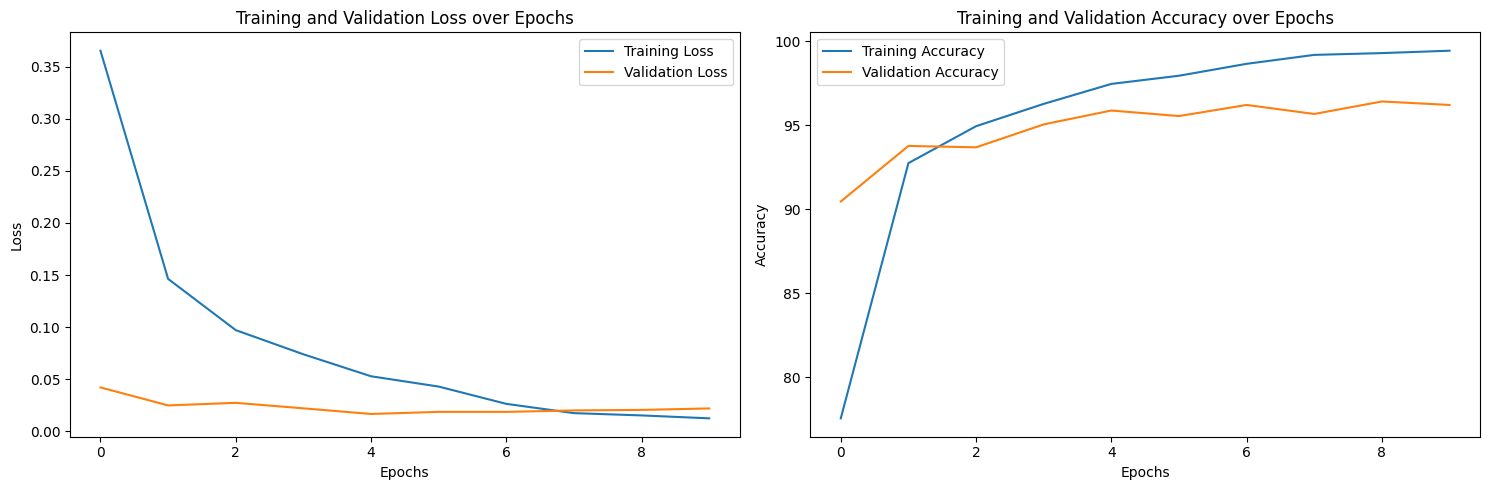

In [77]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_val_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_val_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()
